In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [20]:
try:
    df = pd.read_csv("hospital_employee_attrition_dataset.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
   print("Dataset not found. Upload hospital_employee_attrition_dataset.csv in Google Colab.")

df.head()

Dataset loaded successfully.


,Employee_ID,Hospital,Department,Job_Level,Job_Role,Location,Gender,Age,Education,Employment_Type,...,Night_Shifts_Month,Training_Hours_Year,Patients_Handled_Month,Projects_Count,Promotions_Last_5_Years,Manager_Rating,Distance_From_Home_KM,Salary_Growth_Potential,Attrition_Probability,Attrition
0,HOSP10001,Mangalore Medical Centre,Radiology,L3,Lab Technician,Udupi,Male,32,Diploma,Full-Time,...,13,18,346,9,3,5,17.4,Medium,0.8965,Yes
1,HOSP10002,Apollo Hospital,Administration,L5,Medical Officer,Chennai,Female,28,Master's,Full-Time,...,3,101,355,8,1,3,43.4,Medium,0.8367,No
2,HOSP10003,Fortis Hospital,General Medicine,L1,Resident Doctor,Bengaluru,Male,44,Bachelor's,Part-Time,...,6,41,173,4,1,2,12.3,Medium,0.9269,Yes
3,HOSP10004,Mangalore Medical Centre,Emergency,L4,Staff Nurse,Mangaluru,Female,36,Bachelor's,Full-Time,...,4,19,100,7,2,1,14.5,High,0.9277,Yes
4,HOSP10005,Manipal Hospital,Pediatrics,L5,Consultant Doctor,Mangaluru,Male,24,PhD,Full-Time,...,13,98,106,5,1,3,41.5,Medium,0.8303,Yes


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(list(df.columns))
print("\nData Types:")
print(df.dtypes)

df.info()

Dataset Shape: (1000, 33)

Columns:
['Employee_ID', 'Hospital', 'Department', 'Job_Level', 'Job_Role', 'Location', 'Gender', 'Age', 'Education', 'Employment_Type', 'Work_Mode', 'Shift', 'Years_at_Hospital', 'Years_in_Current_Role', 'Total_Work_Experience', 'Monthly_Salary_INR', 'Annual_Salary_INR', 'Annual_Bonus_INR', 'Job_Satisfaction', 'Work_Life_Balance', 'Performance_Rating', 'Overtime_Hours_Month', 'Overtime', 'Night_Shifts_Month', 'Training_Hours_Year', 'Patients_Handled_Month', 'Projects_Count', 'Promotions_Last_5_Years', 'Manager_Rating', 'Distance_From_Home_KM', 'Salary_Growth_Potential', 'Attrition_Probability', 'Attrition']

Data Types:
Employee_ID                 object
Hospital                    object
Department                  object
Job_Level                   object
Job_Role                    object
Location                    object
Gender                      object
Age                          int64
Education                   object
Employment_Type             o

In [5]:
missing_values = df.isnull().sum()
print(missing_values)

Employee_ID                0
Hospital                   0
Department                 0
Job_Level                  0
Job_Role                   0
Location                   0
Gender                     0
Age                        0
Education                  0
Employment_Type            0
Work_Mode                  0
Shift                      0
Years_at_Hospital          0
Years_in_Current_Role      0
Total_Work_Experience      0
Monthly_Salary_INR         0
Annual_Salary_INR          0
Annual_Bonus_INR           0
Job_Satisfaction           0
Work_Life_Balance          0
Performance_Rating         0
Overtime_Hours_Month       0
Overtime                   0
Night_Shifts_Month         0
Training_Hours_Year        0
Patients_Handled_Month     0
Projects_Count             0
Promotions_Last_5_Years    0
Manager_Rating             0
Distance_From_Home_KM      0
Salary_Growth_Potential    0
Attrition_Probability      0
Attrition                  0
dtype: int64


In [6]:
mean_salary = df["Monthly_Salary_INR"].mean()
median_salary = df["Monthly_Salary_INR"].median()
mode_salary = df["Monthly_Salary_INR"].mode()[0]
variance_salary = df["Monthly_Salary_INR"].var()
std_salary = df["Monthly_Salary_INR"].std()
cv_salary = std_salary / mean_salary

print(f"Mean Salary: {mean_salary:.2f}")
print(f"Median Salary: {median_salary:.2f}")
print(f"Mode Salary: {mode_salary:.2f}")
print(f"Variance: {variance_salary:.2f}")
print(f"Standard Deviation: {std_salary:.2f}")
print(f"Coefficient of Variation: {cv_salary:.2%}")

Mean Salary: 98849.30
Median Salary: 100604.00
Mode Salary: 33389.00
Variance: 2275283360.69
Standard Deviation: 47699.93
Coefficient of Variation: 48.26%


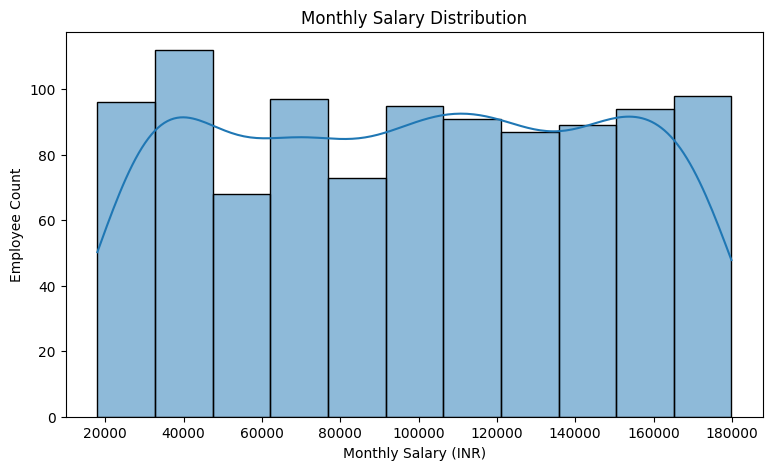

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Monthly_Salary_INR"], kde=True)
plt.title("Monthly Salary Distribution")
plt.xlabel("Monthly Salary (INR)")
plt.ylabel("Employee Count")
plt.show()

In [8]:
Q1 = df["Monthly_Salary_INR"].quantile(0.25)
Q3 = df["Monthly_Salary_INR"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Monthly_Salary_INR"] < lower) |
    (df["Monthly_Salary_INR"] > upper)
]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower:.2f}")
print(f"Upper Bound: {upper:.2f}")
print(f"Outliers Found: {len(outliers)}")

display(outliers.head(10))

Q1: 57108.50
Q3: 141496.50
IQR: 84388.00
Lower Bound: -69473.50
Upper Bound: 268078.50
Outliers Found: 0


,Employee_ID,Hospital,Department,Job_Level,Job_Role,Location,Gender,Age,Education,Employment_Type,...,Night_Shifts_Month,Training_Hours_Year,Patients_Handled_Month,Projects_Count,Promotions_Last_5_Years,Manager_Rating,Distance_From_Home_KM,Salary_Growth_Potential,Attrition_Probability,Attrition


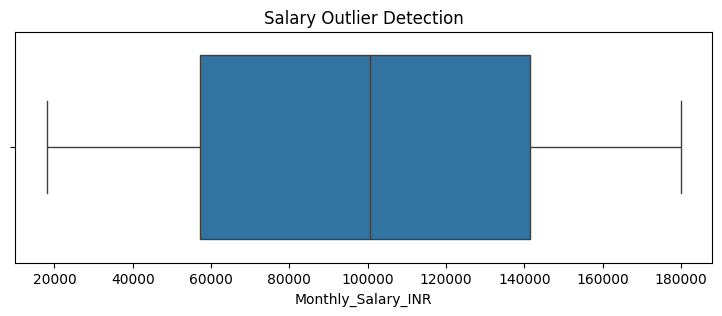

In [9]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=df["Monthly_Salary_INR"])
plt.title("Salary Outlier Detection")
plt.show()

,Monthly_Salary_INR
Attrition,
No,97481.817143
Yes,99139.368485


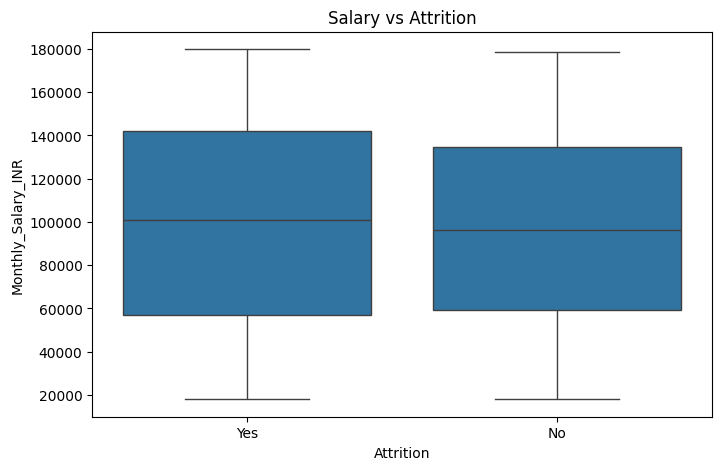

In [10]:
salary_by_attrition = df.groupby("Attrition")["Monthly_Salary_INR"].mean()
display(salary_by_attrition)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Attrition", y="Monthly_Salary_INR", data=df)
plt.title("Salary vs Attrition")
plt.show()

In [11]:
experience_by_attrition = df.groupby("Attrition")["Total_Work_Experience"].mean()
display(experience_by_attrition)

,Total_Work_Experience
Attrition,
No,15.285714
Yes,14.884848


In [12]:
overtime_attrition = pd.crosstab(
    df["Overtime"],
    df["Attrition"],
    normalize="index"
)

display(overtime_attrition)

Attrition,No,Yes
Overtime,,
No,0.362140,0.637860
Yes,0.114927,0.885073


In [13]:
satisfaction_by_attrition = (
    df.groupby("Attrition")["Job_Satisfaction"]
    .mean()
)

display(satisfaction_by_attrition)

,Job_Satisfaction
Attrition,
No,3.234286
Yes,2.906667


In [14]:
df["Attrition_Flag"] = (df["Attrition"] == "Yes").astype(int)

corr_matrix = df.corr(numeric_only=True)

print("Correlation with Attrition:")
print(
    corr_matrix["Attrition_Flag"]
    .sort_values()
)

Correlation with Attrition:
Job_Satisfaction          -0.086929
Projects_Count            -0.079832
Performance_Rating        -0.066598
Work_Life_Balance         -0.040774
Total_Work_Experience     -0.017639
Years_at_Hospital         -0.013110
Patients_Handled_Month    -0.013022
Manager_Rating            -0.011494
Annual_Salary_INR          0.013210
Monthly_Salary_INR         0.013210
Years_in_Current_Role      0.014666
Age                        0.015853
Promotions_Last_5_Years    0.017992
Training_Hours_Year        0.018187
Annual_Bonus_INR           0.047261
Distance_From_Home_KM      0.099949
Night_Shifts_Month         0.107753
Overtime_Hours_Month       0.317602
Attrition_Probability      0.409062
Attrition_Flag             1.000000
Name: Attrition_Flag, dtype: float64


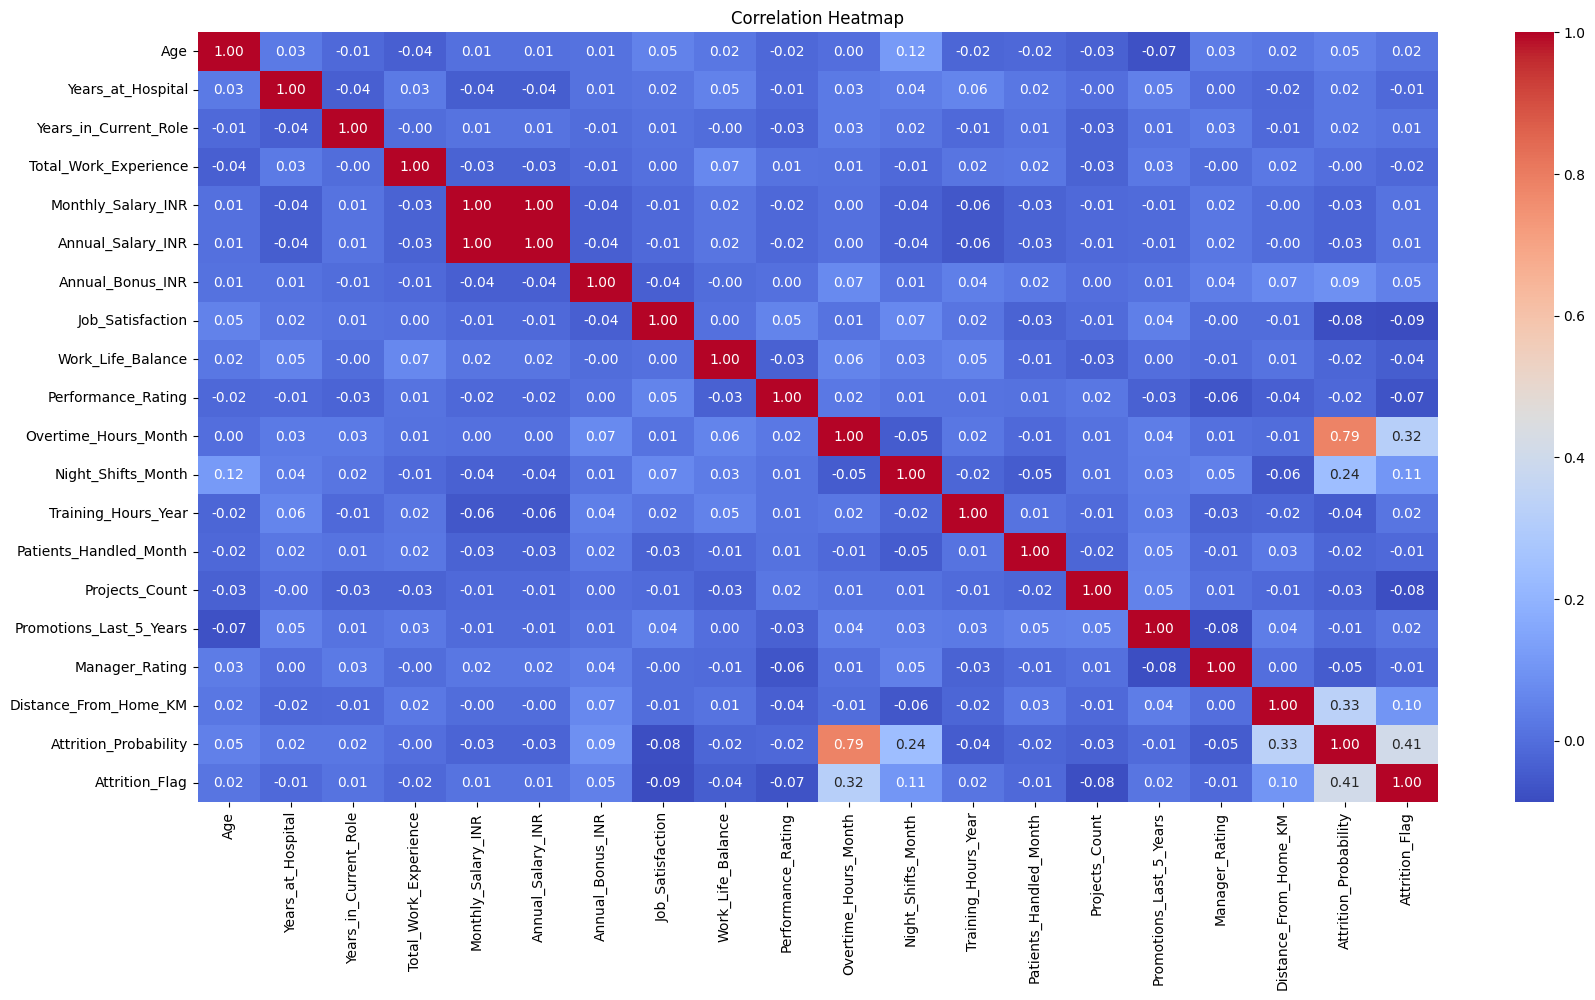

In [16]:
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Overall probability of attrition
overall_attrition_rate = df["Attrition_Flag"].mean()

# Conditional probability: P(Attrition | Low Job Satisfaction)
low_satisfaction = df[
    df["Job_Satisfaction"] <= 2
]

conditional_attrition_rate = (
    low_satisfaction["Attrition_Flag"]
    .mean()
)

print(f"Overall Attrition Rate: {overall_attrition_rate:.2%}")
print(
    "P(Attrition | Low Job Satisfaction): "
    f"{conditional_attrition_rate:.2%}"
)

Overall Attrition Rate: 82.50%
P(Attrition | Low Job Satisfaction): 86.40%


In [18]:
left = df[
    df["Attrition"] == "Yes"
]["Monthly_Salary_INR"]

stayed = df[
    df["Attrition"] == "No"
]["Monthly_Salary_INR"]

t_stat, p_value = stats.ttest_ind(
    left,
    stayed,
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Decision: Reject H0 at the 5% significance level.")
else:
    print("Decision: Insufficient evidence to reject H0 at the 5% significance level.")


t-statistic: 0.426
p-value: 0.6703
Decision: Insufficient evidence to reject H0 at the 5% significance level.


In [19]:
pooled_std = np.sqrt(
    (left.var() + stayed.var()) / 2
)

cohens_d = (
    stayed.mean() - left.mean()
) / pooled_std

print(f"Cohen's d: {cohens_d:.2f}")

Cohen's d: -0.04
